In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [5]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['Target'] = iris.target

In [6]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace = True)

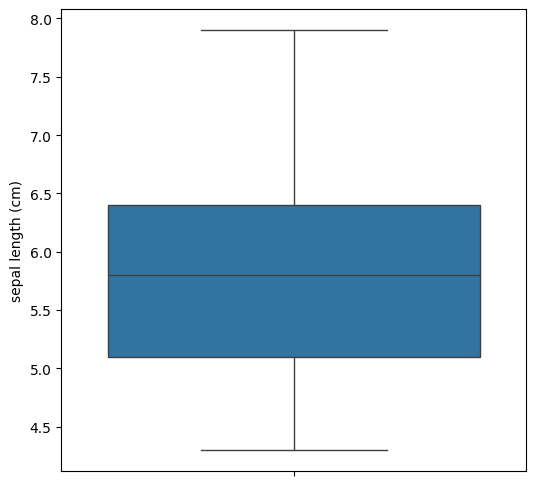

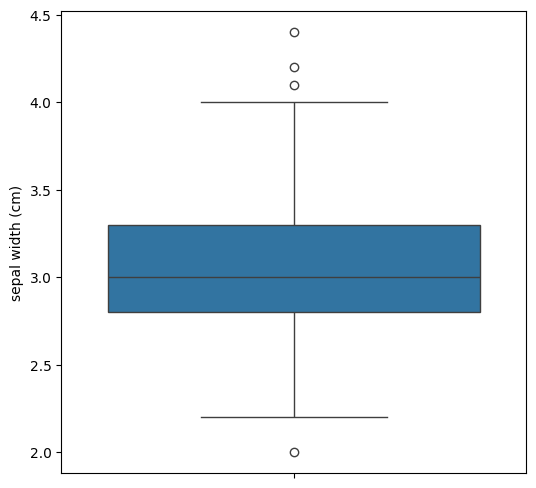

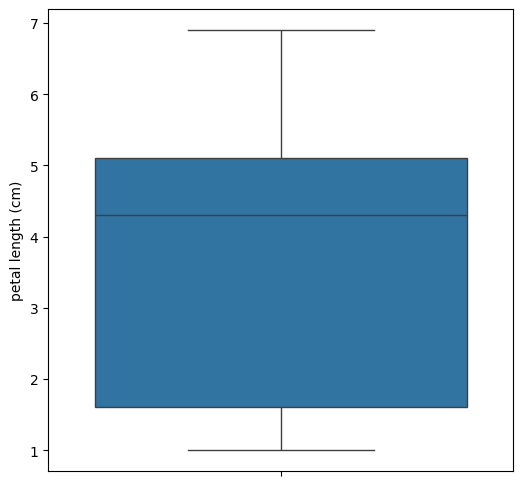

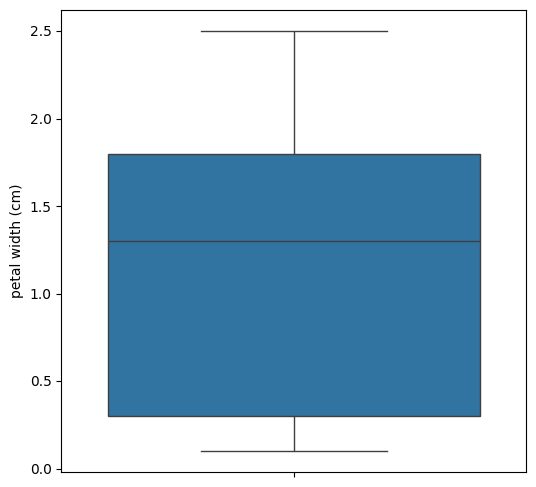

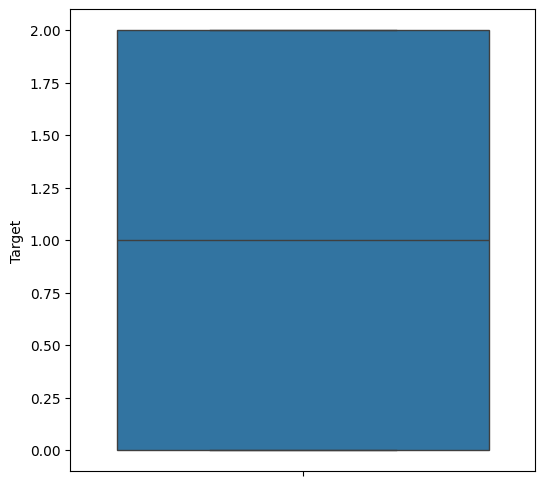

In [15]:
for feature in df.columns:
    plt.figure(figsize = (6, 6))
    sns.boxplot(df[feature])

In [16]:
def handle_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR

        # Trimming Outliers
        # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

        # Capping Outliers
        df.loc[df[col] > upper_bound, col] = upper_bound
        df.loc[df[col] < lower_bound, col] = lower_bound
    
    return df

# Apply outlier handling to the Price and other numerical columns
handle_outliers(df, df.columns)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


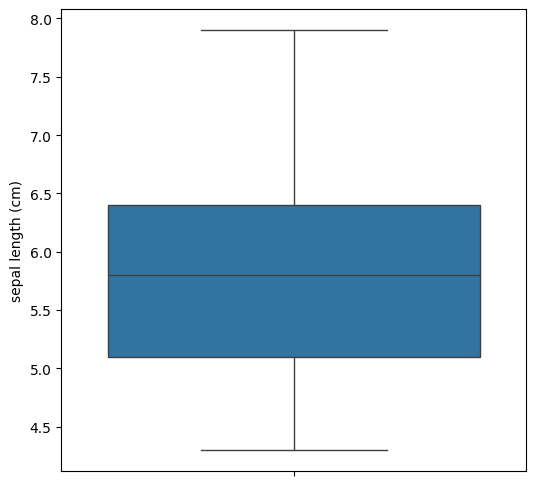

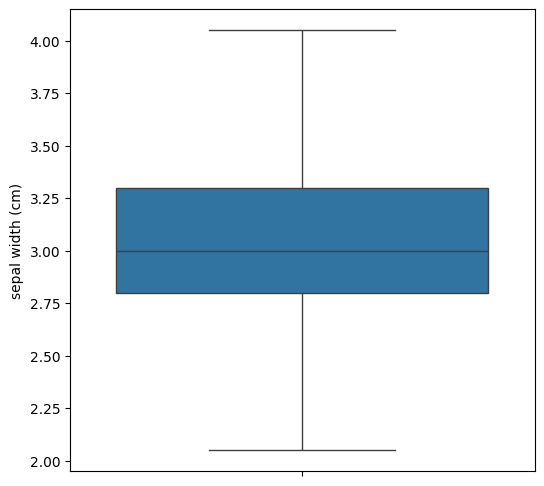

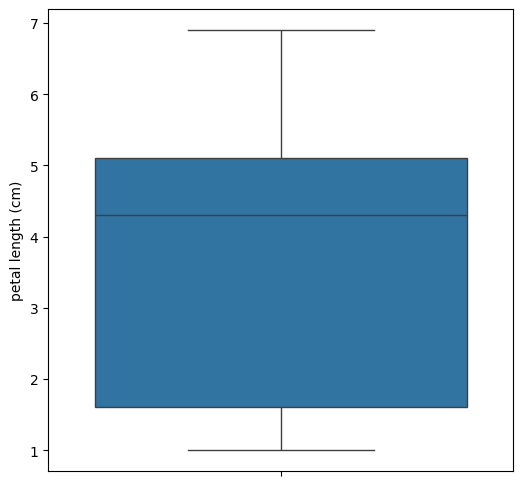

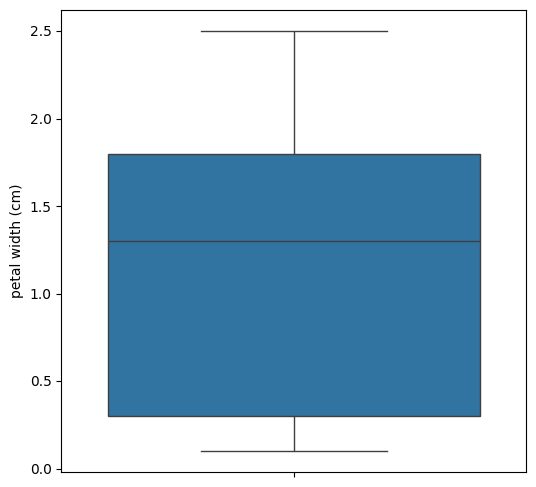

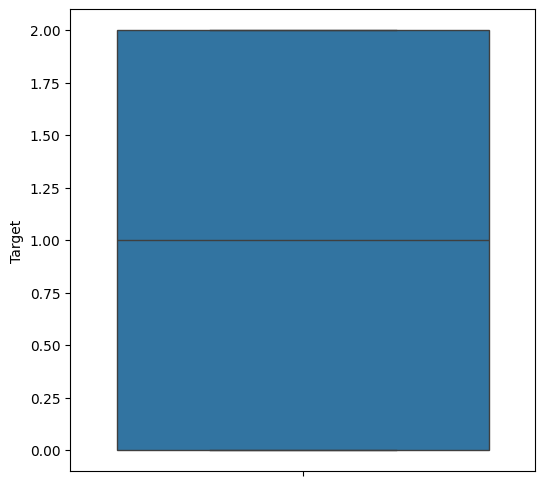

In [17]:
for feature in df.columns:
    plt.figure(figsize = (6, 6))
    sns.boxplot(df[feature])

In [20]:
X = df.drop(columns = 'Target', axis = 1)
y = df['Target']

In [59]:
# Apply Kmeans
kmeans = KMeans(n_clusters = 3, init = 'random', random_state = 42)
kmeans.fit(X)
labels_kmeans = kmeans.labels_
kmeans_centroids = kmeans.cluster_centers_
kmeans_centroids

array([[5.006     , 3.417     , 1.462     , 0.246     ],
       [5.90327869, 2.75      , 4.38196721, 1.42622951],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [53]:
# Apply Kmenas++
kmeans_pp = KMeans(n_clusters=3, init="k-means++", random_state=42)
kmeans_pp.fit(X)
labels_kmeans_pp = kmeans_pp.labels_
kmeans_pp_centroids = kmeans.cluster_centers_

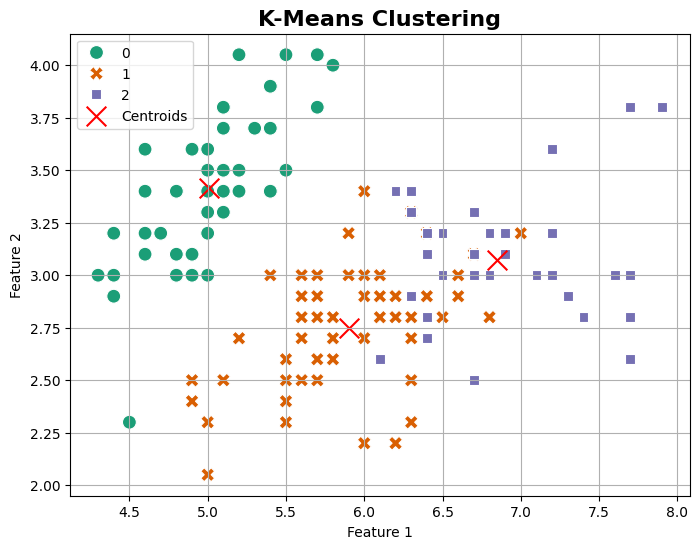

In [79]:
# Visualize kmeans
plt.figure(figsize=(8, 6))

sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=labels_kmeans, s=100, palette='Dark2', style=labels_kmeans)

plt.scatter(kmeans_centroids[:, 0], kmeans_centroids[:, 1], c='red', marker='x', s=200, label='Centroids')

plt.title('K-Means Clustering', fontsize = 16, fontweight = 'bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc = 'best')
plt.grid()
plt.show()

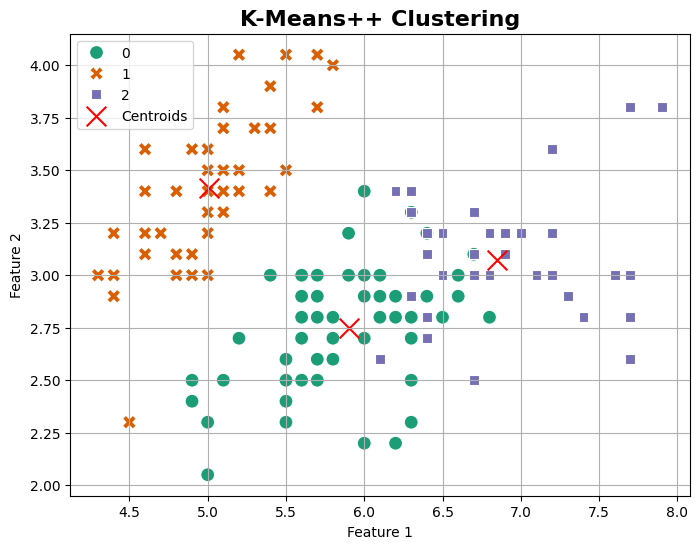

In [83]:
# Visualize kmeans++
plt.figure(figsize=(8, 6))

sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=labels_kmeans_pp, s=100, palette='Dark2', style=labels_kmeans_pp)

plt.scatter(kmeans_pp_centroids[:, 0], kmeans_pp_centroids[:, 1], c='red', marker='x', s=200, label='Centroids')

plt.title('K-Means++ Clustering', fontsize = 16, fontweight = 'bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend(loc='best')
plt.grid()
plt.show()